In [1]:
import matplotlib.pyplot as plt
from google.colab import drive
import time
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/GumbleRIS/RIS_Channels.mat'

Mounted at /content/drive


In [2]:
!pip install scipy

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import math
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
from scipy.io import loadmat

data = loadmat(DATA_PATH)

print(data.keys())
G_all = data['G']
H_all = data['H']
D_all = data['D']

print("Shapes:")
print("G:", G_all.shape)
print("H:", H_all.shape)
print("D:", D_all.shape)

dict_keys(['__header__', '__version__', '__globals__', 'H', 'G', 'D'])
Shapes:
G: (64, 256, 5000)
H: (256, 64, 5000)
D: (64, 64, 5000)


In [19]:
class RISDataset(Dataset):
    def __init__(self, G, H, D):
        self.G = G
        self.H = H
        self.D = D
        self.N = G.shape[2]   # 5000 samples

    def __len__(self):
        return self.N

    def __getitem__(self, idx):

        G = self.G[:, :, idx]      # (64,256)
        H = self.H[:, :, idx]      # (256,64)
        D = self.D[:, :, idx]      # (64,64)

        # normalization
        power = (
            np.mean(np.abs(G)**2) +
            np.mean(np.abs(H)**2) +
            np.mean(np.abs(D)**2)
        )
        scale = np.sqrt(power + 1e-12)

        G = G / scale
        H = H / scale
        D = D / scale

        # reshape for CNN
        H_pad = H.T                # (64,256)
        D_pad = np.zeros((64,256), dtype=np.complex128)
        D_pad[:, :64] = D

        tensor = np.stack([
            np.real(G),
            np.imag(G),
            np.real(H_pad),
            np.imag(H_pad),
            np.real(D_pad),
            np.imag(D_pad)
        ], axis=0)   # (6,64,256)

        return (
            torch.tensor(tensor, dtype=torch.float32),
            torch.tensor(G, dtype=torch.complex64),
            torch.tensor(H, dtype=torch.complex64),
            torch.tensor(D, dtype=torch.complex64)
        )


In [20]:
dataset = RISDataset(G_all, H_all, D_all)

N = len(dataset)
train_size = int(0.6 * N)
val_size = int(0.2 * N)
test_size = N - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=8)
test_loader  = DataLoader(test_set, batch_size=8)

print("Split done.")

Split done.


In [21]:
class GumbelRIS(nn.Module):
    def __init__(self, tau=1.0):
        super().__init__()
        self.tau = tau

        self.conv = nn.Conv2d(6, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, 256*4)

    def forward(self, x, hard=False):
        x = F.relu(self.conv(x))
        x = self.pool(x).view(x.size(0), -1)
        logits = self.fc(x)
        logits = logits.view(-1, 256, 4)

        y = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
        return y, logits

In [22]:
theta = torch.tensor([0, math.pi/2, math.pi, 3*math.pi/2],
                     dtype=torch.float32, device=device)

def construct_phase(y):
    phi = torch.sum(y * theta, dim=2)
    return torch.exp(1j * phi)

In [23]:
def compute_capacity(G, H, D, phi, Pt=20.0, sigma2=1.0):
    batch = G.shape[0]
    capacities = []

    for b in range(batch):
        Phi = torch.diag(phi[b])

        C = G[b] @ Phi @ H[b] + D[b]

        Nr = C.shape[0]
        I = torch.eye(Nr, dtype=torch.complex64, device=device)

        M = I + (Pt/sigma2) * (C @ C.conj().T)

        # Use logdet safely
        sign, logdet = torch.linalg.slogdet(M)

        cap = logdet / torch.log(torch.tensor(2.0, device=device))
        capacities.append(cap.real)

    return torch.mean(torch.stack(capacities))

In [24]:
model = GumbelRIS(tau=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Total parameters:",
      sum(p.numel() for p in model.parameters()))

Total parameters: 35552


In [25]:
# Check average channel magnitude
print("Mean |G|:", np.mean(np.abs(G_all)))
print("Mean |H|:", np.mean(np.abs(H_all)))
print("Mean |D|:", np.mean(np.abs(D_all)))

Mean |G|: 0.0003923006243191256
Mean |H|: 5.8031316903819844e-05
Mean |D|: 6.805325141335878e-06


In [26]:
print("G shape:", G_all.shape)
print("H shape:", H_all.shape)
print("D shape:", D_all.shape)

G shape: (64, 256, 5000)
H shape: (256, 64, 5000)
D shape: (64, 64, 5000)


In [27]:
for epoch in range(epochs):
    model.train()
    model.tau = max(tau_min, tau0 * (anneal_rate ** epoch))

    total_loss = 0

    for x, G, H, D in tqdm(train_loader):
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x)
        phi = construct_phase(y)

        loss = -compute_capacity(G, H, D, phi)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Tau: {model.tau:.4f}")

100%|██████████| 375/375 [00:13<00:00, 27.66it/s]


Epoch 1 | Loss: -32.2763 | Tau: 1.0000


100%|██████████| 375/375 [00:08<00:00, 45.03it/s]


Epoch 2 | Loss: -60.9158 | Tau: 0.9500


100%|██████████| 375/375 [00:08<00:00, 45.64it/s]


...

Epoch 18 | Loss: -65.2655 | Tau: 0.4181


100%|██████████| 375/375 [00:07<00:00, 50.22it/s]


Epoch 19 | Loss: -64.9143 | Tau: 0.3972


100%|██████████| 375/375 [00:08<00:00, 45.31it/s]

Epoch 20 | Loss: -64.9127 | Tau: 0.3774


In [28]:
model.eval()
capacities = []

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x, hard=True)
        phi = construct_phase(y)

        cap = compute_capacity(G, H, D, phi)
        capacities.append(cap.item())

mean_cap = np.mean(capacities)
std_cap = np.std(capacities)

print("Mean Capacity:", mean_cap)
print("Std Dev:", std_cap)

Mean Capacity: 64.26401898193359
Std Dev: 20.919465636374866


In [29]:
import scipy.stats as stats

ci = stats.t.interval(
    0.95,
    len(capacities)-1,
    loc=mean_cap,
    scale=std_cap/np.sqrt(len(capacities))
)

print("95% CI:", ci)

95% CI: (np.float64(60.56060005190219), np.float64(67.96743791196499))


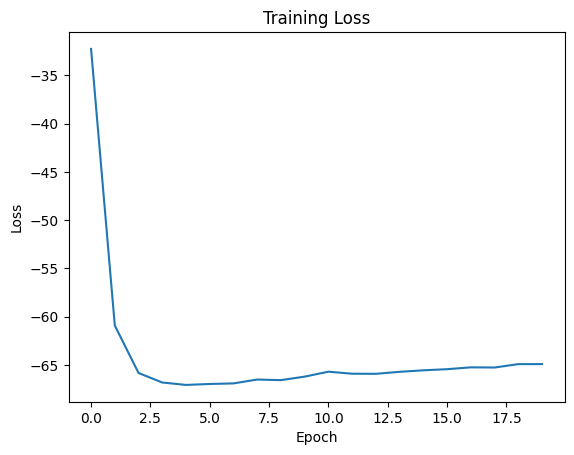

In [30]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [31]:
from collections import Counter

model.eval()
phase_counts = Counter()

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)

        y, _ = model(x, hard=True)
        phi = torch.sum(y * theta, dim=2)  # phase angles

        # Flatten batch
        phi_flat = phi.cpu().numpy().flatten()

        # Convert to discrete bins
        for val in phi_flat:
            if np.isclose(val, 0):
                phase_counts["0"] += 1
            elif np.isclose(val, np.pi/2):
                phase_counts["pi/2"] += 1
            elif np.isclose(val, np.pi):
                phase_counts["pi"] += 1
            elif np.isclose(val, 3*np.pi/2):
                phase_counts["3pi/2"] += 1

print("Learned 2-bit Phase Distribution:")
for k, v in phase_counts.items():
    print(f"{k}: {v}")

Learned 2-bit Phase Distribution:
0: 61051
pi/2: 69498
pi: 65035
3pi/2: 60416


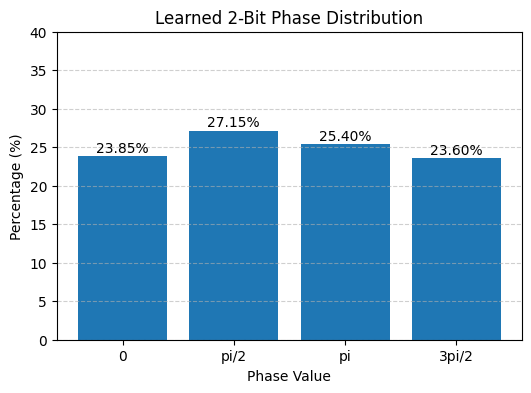

In [32]:
import matplotlib.pyplot as plt

# Convert to percentages
total = sum(phase_counts.values())

labels = list(phase_counts.keys())
percentages = [100 * phase_counts[k] / total for k in labels]

# -----------------------
# BAR PLOT
# -----------------------
plt.figure(figsize=(6,4))
bars = plt.bar(labels, percentages)

plt.title("Learned 2-Bit Phase Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Phase Value")

# Add value labels on bars
for i, v in enumerate(percentages):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(0, 40)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()